# VWAP Trend Trading — Proper Implementation (V2)

**Reference:** Zarattini & Aziz (2023) "VWAP: The Holy Grail for Day Trading Systems"
**Paper result:** 671% return on QQQ, Sharpe 2.1, MaxDD 9.4% (Jan 2018 – Sep 2023)

## Exact Rules from Paper:
1. Wait for first candle after 9:30am ET
2. If close > cumulative daily VWAP → LONG, else → SHORT
3. Stop/reverse: when candle **closes** on the other side of VWAP
4. Always in position during RTH — flip on VWAP cross
5. Close everything at 4:00pm ET — no overnight holds
6. Position sizing: 100% of equity
7. Commission: $0.0005 per share

**V2 fix:** Compute cumulative daily VWAP manually (Alpaca's vwap field is per-bar, not daily cumulative).

## 1. Setup

In [21]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import time as dt_time
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from _shared.loaders_data import fetch_historical_data
from _shared.fees import calculate_fees
from _shared.metrics import evaluate_strategy, print_metrics
from _shared.plotting import plot_equity_curve, plot_trade_returns, plot_yearly_returns
from _shared.significance import full_significance_report, print_significance_report
from _shared.results import save_trades

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Configuration

In [22]:
SYMBOL = "QQQ"
START_DATE = "2018-01-01"
END_DATE = "2026-04-01"
STARTING_CAPITAL = 25_000  # Match paper
COMMISSION_PER_SHARE = 0.0005

STRATEGY_NAME = "VWAP Trend Trading"
SAVE_NAME = "vwap_trend"

RTH_START = dt_time(9, 30)
#RTH_FIRST_TRADE = dt_time(9, 35)  # Wait 1 bar after open
RTH_FIRST_TRADE = dt_time(9, 31)  # Wait 1 min after open (paper says 9:31)
RTH_END = dt_time(15, 55)

## 3. Fetch Data & Compute Cumulative Daily VWAP

In [23]:
#data_dict = fetch_historical_data([SYMBOL], TimeFrame(5, TimeFrameUnit.Minute), START_DATE, END_DATE)
data_dict = fetch_historical_data([SYMBOL], TimeFrame(1, TimeFrameUnit.Minute), START_DATE, END_DATE)
df = data_dict[SYMBOL].copy()
if df.index.tz is None:
    df.index = df.index.tz_localize("UTC").tz_convert("US/Eastern")
else:
    df.index = df.index.tz_convert("US/Eastern")

df = df.reset_index()
df["date"] = df["timestamp"].dt.date
df["time"] = df["timestamp"].dt.time

# Keep only RTH bars
df = df[(df["time"] >= RTH_START) & (df["time"] < dt_time(16, 0))].copy()
df = df.sort_values("timestamp").reset_index(drop=True)

# ═══════════════════════════════════════════════════
# COMPUTE CUMULATIVE DAILY VWAP (this is the key fix)
# Paper uses running daily VWAP, NOT per-bar VWAP
# ═══════════════════════════════════════════════════
df["hlc3"] = (df["high"] + df["low"] + df["close"]) / 3
df["hlc3_vol"] = df["hlc3"] * df["volume"]
df["cum_vol"] = df.groupby("date")["volume"].cumsum()
df["cum_hlc3_vol"] = df.groupby("date")["hlc3_vol"].cumsum()
df["daily_vwap"] = df["cum_hlc3_vol"] / df["cum_vol"]

# Verify: daily VWAP should be smooth within each day
print(f"RTH 5-min bars: {len(df):,}")
print(f"Trading days: {df['date'].nunique():,}")

# Show a sample day to verify VWAP is smooth
sample_date = df["date"].unique()[100]
sample = df[df["date"] == sample_date]
print(f"\nSample day ({sample_date}):")
print(f"  Bars: {len(sample)}")
print(f"  Close range: ${sample['close'].min():.2f} - ${sample['close'].max():.2f}")
print(f"  Daily VWAP range: ${sample['daily_vwap'].min():.2f} - ${sample['daily_vwap'].max():.2f}")
print(f"  Alpaca vwap range: ${sample['vwap'].min():.2f} - ${sample['vwap'].max():.2f}")
print(f"  Daily VWAP std: ${sample['daily_vwap'].std():.4f} (should be small/smooth)")
print(f"  Alpaca vwap std: ${sample['vwap'].std():.4f} (likely more volatile)")

Fetching QQQ...
  1,681,296 bars
RTH 5-min bars: 805,883
Trading days: 2,072

Sample day (2018-05-25):
  Bars: 390
  Close range: $160.21 - $161.18
  Daily VWAP range: $160.42 - $160.83
  Alpaca vwap range: $160.26 - $161.15
  Daily VWAP std: $0.0987 (should be small/smooth)
  Alpaca vwap std: $0.2007 (likely more volatile)


## 4. VWAP Trend Trading Engine

Uses `daily_vwap` (cumulative) instead of Alpaca's per-bar `vwap`.

In [24]:
def run_vwap_trend(df, starting_capital, commission_per_share=0.0005):
    equity = starting_capital
    trades = []
    
    for date, day_df in df.groupby("date"):
        day_df = day_df.sort_values("timestamp").reset_index(drop=True)
        
        if len(day_df) < 5:
            continue
        
        # Wait 1 bar after open (index 0 = 9:30, index 1 = 9:35)
        first_bar_idx = 1
        if first_bar_idx >= len(day_df):
            continue
        
        first_bar = day_df.iloc[first_bar_idx]
        vwap_val = first_bar["daily_vwap"]
        if pd.isna(vwap_val) or vwap_val == 0:
            continue
        
        # Initial position based on close vs daily VWAP
        if first_bar["close"] > vwap_val:
            position = "long"
        elif first_bar["close"] < vwap_val:
            position = "short"
        else:
            continue
        
        entry_price = first_bar["close"]
        entry_time = first_bar["timestamp"]
        shares = int(equity / entry_price)
        
        if shares <= 0:
            continue
        
        for i in range(first_bar_idx + 1, len(day_df)):
            bar = day_df.iloc[i]
            bar_close = bar["close"]
            bar_vwap = bar["daily_vwap"]
            
            if pd.isna(bar_vwap) or bar_vwap == 0:
                continue
            
            # Flip when candle CLOSES on other side of cumulative daily VWAP
            should_flip = False
            if position == "long" and bar_close < bar_vwap:
                should_flip = True
            elif position == "short" and bar_close > bar_vwap:
                should_flip = True
            
            is_last_bar = (i == len(day_df) - 1) or (bar["time"] >= RTH_END)
            
            if should_flip or is_last_bar:
                exit_price = bar_close
                
                if position == "long":
                    gross = shares * (exit_price - entry_price)
                else:
                    gross = shares * (entry_price - exit_price)
                
                commission = shares * commission_per_share * 2
                net = gross - commission
                eq_before = equity
                equity += net
                
                trades.append({
                    "entry_time": entry_time,
                    "exit_time": bar["timestamp"],
                    "position": position,
                    "entry_price": round(entry_price, 4),
                    "exit_price": round(exit_price, 4),
                    "exit_reason": "eod_close" if is_last_bar else "vwap_cross",
                    "risk": round(abs(exit_price - entry_price), 4),
                    "shares": shares,
                    "gross_pnl": round(gross, 2),
                    "fees": round(commission, 2),
                    "net_pnl": round(net, 2),
                    "equity_before": round(eq_before, 2),
                    "equity": round(equity, 2),
                })
                
                if should_flip and not is_last_bar:
                    position = "short" if position == "long" else "long"
                    entry_price = bar_close
                    entry_time = bar["timestamp"]
                    shares = int(equity / entry_price) if equity > 0 else 0
                    if shares <= 0:
                        break
                else:
                    break
    
    if not trades:
        print("No trades generated!")
        return pd.DataFrame()
    
    results = pd.DataFrame(trades)
    results["entry_time"] = pd.to_datetime(results["entry_time"])
    results["exit_time"] = pd.to_datetime(results["exit_time"])
    return results

results = run_vwap_trend(df, STARTING_CAPITAL, COMMISSION_PER_SHARE)
print(f"Total trades: {len(results):,}")

if not results.empty:
    longs = (results["position"] == "long").sum()
    shorts = (results["position"] == "short").sum()
    vwap_exits = (results["exit_reason"] == "vwap_cross").sum()
    eod_exits = (results["exit_reason"] == "eod_close").sum()
    days = df["date"].nunique()
    
    print(f"  Long trades: {longs:,}")
    print(f"  Short trades: {shorts:,}")
    print(f"  VWAP cross exits: {vwap_exits:,}")
    print(f"  EOD close exits: {eod_exits:,}")
    print(f"  Avg trades/day: {len(results) / days:.1f}")
    
    wins = (results["net_pnl"] > 0).sum()
    print(f"  Hit ratio: {wins/len(results)*100:.1f}%")
    
    avg_win = results[results["net_pnl"]>0]["net_pnl"].mean()
    avg_loss = results[results["net_pnl"]<0]["net_pnl"].mean()
    print(f"  Avg win: ${avg_win:.2f}")
    print(f"  Avg loss: ${avg_loss:.2f}")
    if avg_loss != 0:
        print(f"  Gain:Loss ratio: {abs(avg_win/avg_loss):.2f}")
    
    # Paper comparison
    print(f"\n  Paper targets: ~15 trades/day, 17% hit ratio, 5.67 G:L ratio")

Total trades: 32,729
  Long trades: 16,449
  Short trades: 16,280
  VWAP cross exits: 30,659
  EOD close exits: 2,070
  Avg trades/day: 15.8
  Hit ratio: 16.6%
  Avg win: $368.61
  Avg loss: $-67.55
  Gain:Loss ratio: 5.46

  Paper targets: ~15 trades/day, 17% hit ratio, 5.67 G:L ratio


## 5. Analysis

  Strategy             VWAP Trend Trading
  Total Return             656.46%
  Annualized                18.46
  Max Drawdown             -12.36%
  Sharpe                     0.36
  Sortino                    1.55
  Profit Factor              1.09
  Trades               32729
  Win Rate                  16.64%
  Avg Win              $      368.61
  Avg Loss             $      -67.55
  Long Trades          16449
  Long PnL             $  100,263.84
  Long WR                   17.05%
  Short Trades         16280
  Short PnL            $   63,850.46
  Short WR                  16.22%
  Total Fees           $    9,624.12
  Final Equity         $  189,114.46

Yearly Returns:
  2018: 42.13%
  2019: 5.46%
  2020: 61.67%
  2021: 42.46%
  2022: 60.75%
  2023: 6.86%
  2024: 22.11%
  2025: 10.24%
  2026: -5.24%


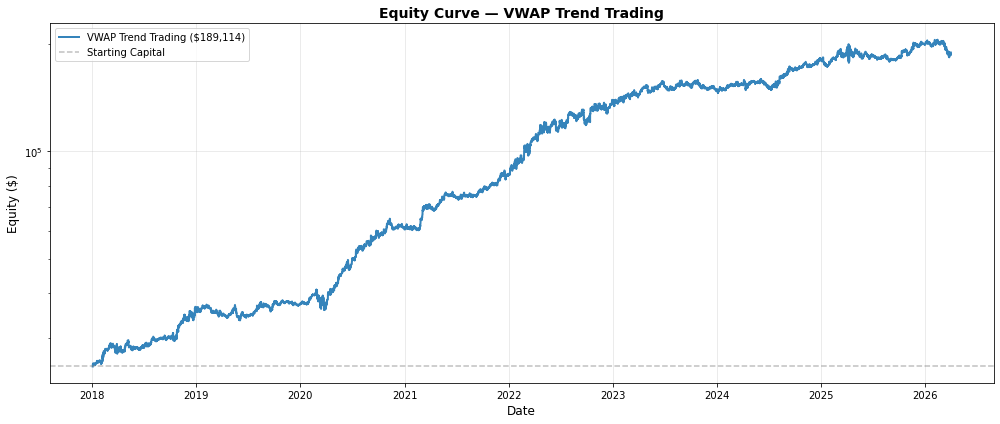

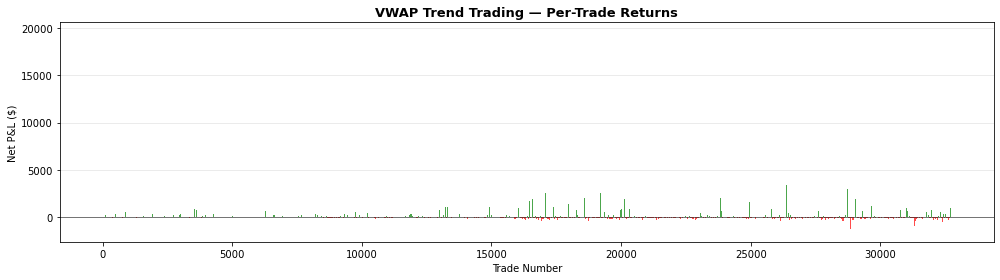

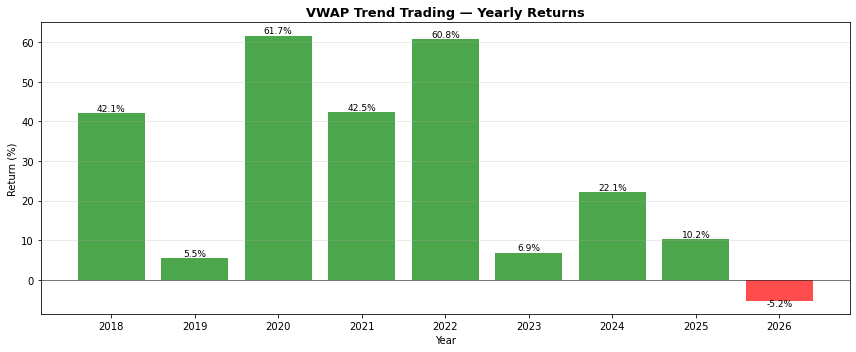

In [25]:
if not results.empty:
    metrics = evaluate_strategy(results, STRATEGY_NAME, starting_capital=STARTING_CAPITAL)
    print_metrics(metrics)
    plot_equity_curve(results, label=STRATEGY_NAME, starting_capital=STARTING_CAPITAL)
    plot_trade_returns(results, title=f"{STRATEGY_NAME} — Per-Trade Returns")
    plot_yearly_returns(metrics, title=f"{STRATEGY_NAME} — Yearly Returns")

## 6. Significance

In [26]:
if not results.empty and len(results) >= 5:
    report = full_significance_report(results, strategy_name=STRATEGY_NAME)
    print_significance_report(report)


STATISTICAL SIGNIFICANCE — VWAP Trend Trading

1. t-test (returns > 0)
   Mean return:  0.0066% per trade
   t-statistic:  4.149
   p-value:      1.7e-05
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   0.3641
   95% CI:            [0.2055, 0.5147]
   % below zero:      0.0%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   0.3641
   p-value:           0.0
   Significant:       YES

──────────────────────────────────────────────────────────────────────
VERDICT: SIGNIFICANT (strong) (3/3 tests pass)


## 7. Daily PnL

Daily PnL stats:
  Trading days: 2,070
  Avg daily PnL: $79.28
  Best day: $10764.01
  Worst day: $-16104.49
  Daily win rate: 54.4%


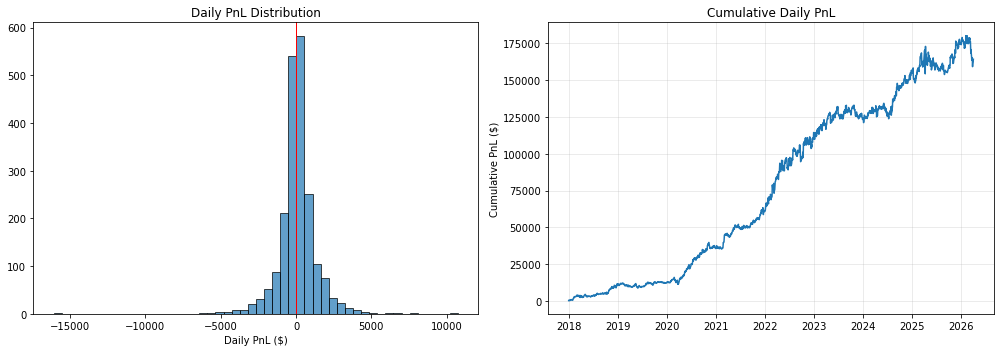

In [27]:
if not results.empty:
    results["trade_date"] = results["exit_time"].dt.date
    daily_pnl = results.groupby("trade_date")["net_pnl"].sum()
    
    print(f"Daily PnL stats:")
    print(f"  Trading days: {len(daily_pnl):,}")
    print(f"  Avg daily PnL: ${daily_pnl.mean():.2f}")
    print(f"  Best day: ${daily_pnl.max():.2f}")
    print(f"  Worst day: ${daily_pnl.min():.2f}")
    print(f"  Daily win rate: {(daily_pnl > 0).mean()*100:.1f}%")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    ax.hist(np.array(daily_pnl), bins=50, alpha=0.7, edgecolor="black")
    ax.axvline(0, color="red", linewidth=1)
    ax.set_xlabel("Daily PnL ($)")
    ax.set_title("Daily PnL Distribution")
    
    ax = axes[1]
    cum_pnl = daily_pnl.cumsum()
    ax.plot(np.array(cum_pnl.index), np.array(cum_pnl.values), linewidth=1.5)
    ax.set_ylabel("Cumulative PnL ($)")
    ax.set_title("Cumulative Daily PnL")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8. Save

In [28]:
if not results.empty:
    save_trades(results, SAVE_NAME)

Saved 32729 trades → results\vwap_trend_trades.csv
